# Notebook 3 — Avaliação, Auto-Retraining e Governança

## Aula 7: Otimizações e Escala no Monitoramento de Drift

### Objetivos

1. Avaliar a **qualidade da detecção de drift** comparando alertas com ground truth.
2. Analisar o **impacto do drift** no desempenho do modelo de fraude (precision, recall, F1).
3. Implementar **triggers automáticos de retraining** baseados em PSI e K–S.
4. Gerar **playbooks de drift** com políticas de resposta conforme severidade.
5. Consolidar métricas e relatório de monitoramento para governança.

### Conexão com o Documento 04

> *"Detectar drift sem reagir é 'monitorar por esporte'. Um sistema completo precisa
> traduzir métricas em decisões, e decisões em ações com rastreabilidade."*
> — DOCUMENTO_AULA_7.md, seção 'Drift, observabilidade e governança'

### Vídeos Relacionados

- **Vídeo 7.3**: Monitoramento de drift com amostragem e janelas deslizantes.
- **Vídeo 7.4**: Escala e auto-retraining em produção.

In [1]:
# Imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)

# Adicionar diretório pai ao path para importar src/
sys.path.insert(0, str(Path.cwd().parent))

from src.data_preprocessing import DataPreprocessor
from src.model import DriftMonitor
from src.training import train_model, train_sliding_window_pipeline
from src.evaluation import (
    calculate_metrics,
    evaluate_drift_detection,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_psi_timeline,
    plot_distribution_comparison,
)
from src.utils import load_model, save_metrics, emit_alert, format_drift_report

# Configurações de visualização
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

%matplotlib inline

## 1. Carregar Dados e Modelo Treinado

Carregamos o modelo de fraude treinado no Notebook 02 (baseline meses 1–3)
e avaliamos seu desempenho em janelas com diferentes níveis de drift.

In [3]:
# Carregar dados
preprocessor = DataPreprocessor(random_state=42)
df = preprocessor.load_data("../data/raw/finbank_transactions.csv")
df = preprocessor.clean_data(df)

# Carregar modelo treinado
clf = load_model("../outputs/models/fraud_classifier.pkl")

# Carregar lista de features
from src.utils import load_config
train_config = load_config("../outputs/models/train_config.json")
train_features = train_config["train_features"]

print(f"Modelo: {type(clf).__name__}")
print(f"Features: {len(train_features)}")
print(f"Dataset: {len(df)} transações")

Modelo: GradientBoostingClassifier
Features: 13
Dataset: 10000 transações


## 2. Impacto do Drift no Desempenho do Modelo

Avaliamos como o drift degrada as métricas do modelo mês a mês.
Conforme discutido na seção 'Saiba Mais':
> *"Sistemas de ML são, por natureza, sistemas sociotécnicos: o modelo é treinado
> com dados que representam um recorte do mundo, mas o mundo continua mudando."*

In [4]:
# Avaliar desempenho do modelo por mês
performance_by_month = []

for month in sorted(df["month"].unique()):
    month_df = df[df["month"] == month].copy()
    month_prepared = preprocessor.prepare_features(month_df, encode_categorical=True)

    # Garantir que todas as features existam
    for feat in train_features:
        if feat not in month_prepared.columns:
            month_prepared[feat] = 0

    X_month = month_prepared[train_features].values
    y_month = month_prepared["is_fraud"].values

    y_pred = clf.predict(X_month)
    y_proba = clf.predict_proba(X_month)[:, 1]

    # Evitar divisão por zero com zero_division=0
    performance_by_month.append({
        "Mês": month,
        "n_amostras": len(month_df),
        "taxa_fraude": y_month.mean(),
        "precision": precision_score(y_month, y_pred, zero_division=0),
        "recall": recall_score(y_month, y_pred, zero_division=0),
        "f1": f1_score(y_month, y_pred, zero_division=0),
    })

perf_df = pd.DataFrame(performance_by_month)
print("Desempenho do modelo de fraude por mês:")
perf_df.round(4)

Desempenho do modelo de fraude por mês:


,Mês,n_amostras,taxa_fraude,precision,recall,f1
0,1,1250,0.0312,1.0000,0.5641,0.7213
1,2,1250,0.0320,1.0000,0.6500,0.7879
2,3,1250,0.0224,1.0000,0.6786,0.8085
3,4,1250,0.0336,0.0000,0.0000,0.0000
4,5,1250,0.0416,0.0000,0.0000,0.0000
5,6,1250,0.0472,0.0500,0.0169,0.0253
6,7,1250,0.0800,0.0962,0.0500,0.0658
7,8,1250,0.0816,0.0000,0.0000,0.0000


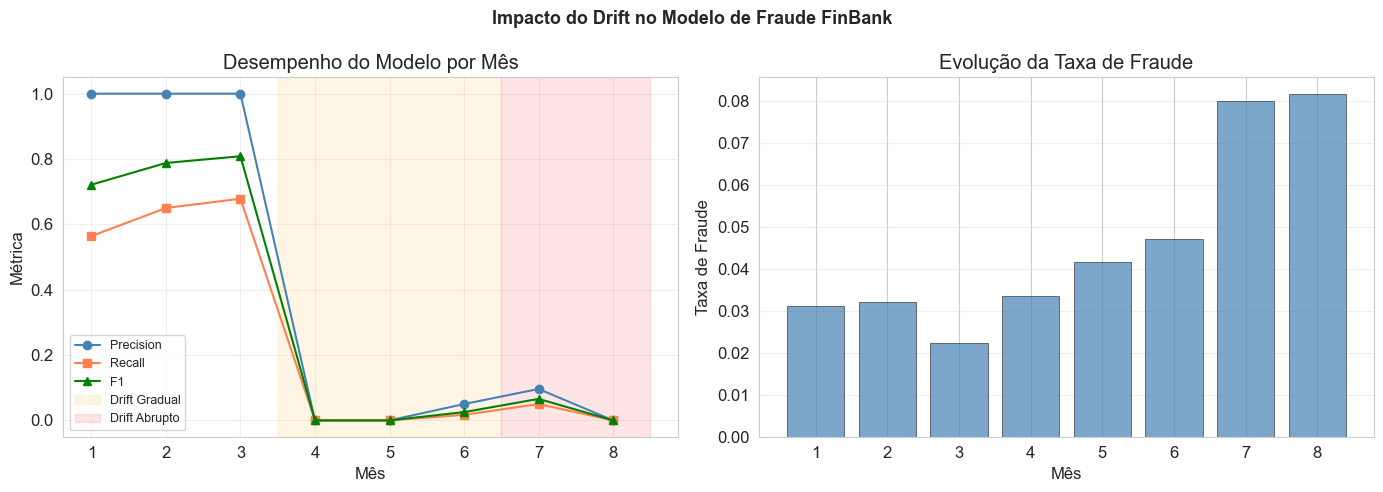

In [5]:
# Visualizar degradação do desempenho
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Métricas de classificação
axes[0].plot(perf_df["Mês"], perf_df["precision"], marker="o", label="Precision", color="steelblue")
axes[0].plot(perf_df["Mês"], perf_df["recall"], marker="s", label="Recall", color="coral")
axes[0].plot(perf_df["Mês"], perf_df["f1"], marker="^", label="F1", color="green")
axes[0].axvspan(3.5, 6.5, alpha=0.1, color="orange", label="Drift Gradual")
axes[0].axvspan(6.5, 8.5, alpha=0.1, color="red", label="Drift Abrupto")
axes[0].set_xlabel("Mês")
axes[0].set_ylabel("Métrica")
axes[0].set_title("Desempenho do Modelo por Mês")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].set_xticks(range(1, 9))

# Taxa de fraude
axes[1].bar(perf_df["Mês"], perf_df["taxa_fraude"], color="steelblue", alpha=0.7,
            edgecolor="black", linewidth=0.5)
axes[1].set_xlabel("Mês")
axes[1].set_ylabel("Taxa de Fraude")
axes[1].set_title("Evolução da Taxa de Fraude")
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_xticks(range(1, 9))

plt.suptitle("Impacto do Drift no Modelo de Fraude FinBank",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/degradacao_modelo.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Matriz de Confusão e ROC — Com e Sem Drift

Comparamos a performance do modelo no baseline (meses 1-3) vs.
período de drift abrupto (meses 7-8).

In [6]:
# Preparar dados baseline e drift abrupto
baseline_df = df[df["month"].isin([1, 2, 3])].copy()
abrupto_df = df[df["month"].isin([7, 8])].copy()

for subset_df, label in [(baseline_df, "Baseline"), (abrupto_df, "Drift Abrupto")]:
    prepared = preprocessor.prepare_features(subset_df, encode_categorical=True)
    for feat in train_features:
        if feat not in prepared.columns:
            prepared[feat] = 0

    X = prepared[train_features].values
    y = prepared["is_fraud"].values
    y_pred = clf.predict(X)

    print(f"\n{'='*40}")
    print(f"Classification Report — {label}")
    print(f"{'='*40}")
    print(classification_report(y, y_pred, target_names=["Legítima", "Fraude"],
                                 zero_division=0))


Classification Report — Baseline
              precision    recall  f1-score   support

    Legítima       0.99      1.00      0.99      3643
      Fraude       1.00      0.63      0.77       107

    accuracy                           0.99      3750
   macro avg       0.99      0.81      0.88      3750
weighted avg       0.99      0.99      0.99      3750


Classification Report — Drift Abrupto
              precision    recall  f1-score   support

    Legítima       0.92      0.96      0.94      2298
      Fraude       0.05      0.02      0.03       202

    accuracy                           0.89      2500
   macro avg       0.49      0.49      0.49      2500
weighted avg       0.85      0.89      0.87      2500



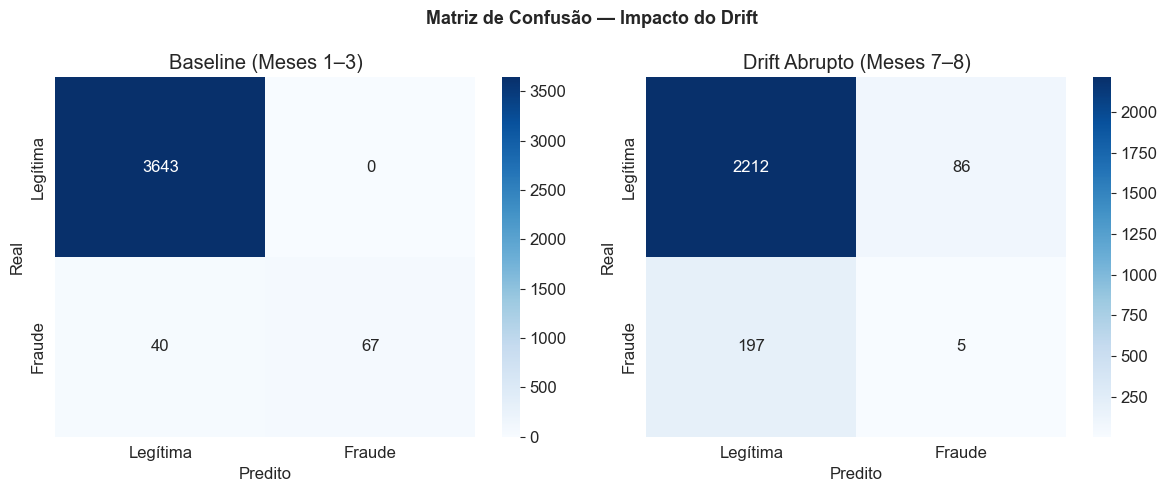

In [7]:
# Matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (subset_df, title) in zip(axes, [
    (baseline_df, "Baseline (Meses 1–3)"),
    (abrupto_df, "Drift Abrupto (Meses 7–8)"),
]):
    prepared = preprocessor.prepare_features(subset_df, encode_categorical=True)
    for feat in train_features:
        if feat not in prepared.columns:
            prepared[feat] = 0

    X = prepared[train_features].values
    y = prepared["is_fraud"].values
    y_pred = clf.predict(X)

    from sklearn.metrics import confusion_matrix as sk_cm
    cm = sk_cm(y, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legítima", "Fraude"],
                yticklabels=["Legítima", "Fraude"])
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    ax.set_title(title)

plt.suptitle("Matriz de Confusão — Impacto do Drift", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Avaliação da Qualidade de Detecção de Drift

Comparamos os alertas do pipeline de monitoramento com o ground truth
(sabemos que drift foi injetado nos meses 4-8, com intensidade crescente).

Esperamos drift significativo a partir do mês 4 (gradual) e forte nos meses 7-8.

In [8]:
# Re-executar pipeline de janelas deslizantes
monitor = DriftMonitor(n_bins=10, psi_threshold=0.25, psi_warning=0.10, ks_alpha=0.05)
feature_columns = DataPreprocessor.NUMERIC_FEATURES

results = train_sliding_window_pipeline(
    df, feature_columns, monitor,
    window_size=1, step_size=1,
    baseline_months=(1, 2, 3),
)

# Métricas agregadas
metrics = calculate_metrics(results)
print("Métricas agregadas do pipeline de monitoramento:")
for k, v in metrics.items():
    print(f"  {k}: {v}")

c:\Personal\Others\FIAP\POSTECH-DATA_DRIFT\9mlet-data-drift\07_otimizacoes_e_escala_no_monitoramento_de_drift\src\model.py:218: RuntimeWarning: invalid value encountered in divide
  q = np.clip(q / q.sum(), self.eps, None)


Métricas agregadas do pipeline de monitoramento:
  n_windows: 5
  critical_windows: 5
  warning_windows: 0
  ok_windows: 0
  critical_rate: 1.0
  mean_psi_overall: nan
  max_psi_overall: nan


In [9]:
# Avaliar qualidade da detecção contra ground truth
# Ground truth: drift gradual meses 4-6 (índices 0-2), abrupto 7-8 (índices 3-4)
# Esperamos alertas a partir do drift gradual
expected_drift_indices = list(range(len(results)))  # Todos os meses pós-baseline

eval_result = evaluate_drift_detection(
    results,
    expected_drift_windows=expected_drift_indices,
)

print("\nAvaliação da Detecção de Drift (ground truth = todos meses pós-baseline):")
for k, v in eval_result.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")


Avaliação da Detecção de Drift (ground truth = todos meses pós-baseline):
  true_positives: 5
  false_positives: 0
  false_negatives: 0
  precision: 1.0000
  recall: 1.0000
  f1_score: 1.0000


## 5. Trigger Automático de Retraining

Implementa a lógica de auto-retraining descrita na Videoaula 4:

> *"Triggers automáticos de retraining baseados em drift detectado"*

### Playbook de Drift (conforme DOCUMENTO_AULA_7.md)

1. **PSI crítico por k janelas → Incidente** + investigação.
2. **Múltiplas features com drift → Mudança sistêmica** (bug de coleta, migração).
3. **Drift + queda de performance → Priorizar retraining**.
4. **Drift sem queda de performance → Registrar e acompanhar**.

In [10]:
# Simulação de auto-retraining baseado em drift
PSI_CRITICO = 0.25
ALFA = 0.05
CONSECUTIVE_THRESHOLD = 2  # Janelas consecutivas para trigger

consecutive_alerts = 0
retrain_events = []

print("Simulação de Auto-Retraining:\n")

for i, r in enumerate(results):
    months = r["window_months"]
    alert = r["alert_level"]
    score = r["aggregate_score"]
    n_drift = score.get("n_features_with_drift", 0)
    n_total = score.get("n_features_total", 1)

    if alert in ("CRITICAL", "WARNING"):
        consecutive_alerts += 1
    else:
        consecutive_alerts = 0

    # Decisão conforme playbook
    decision = "MONITORING"
    if alert == "CRITICAL" and consecutive_alerts >= CONSECUTIVE_THRESHOLD:
        decision = "RETRAIN"
        retrain_events.append(months)
    elif n_drift >= n_total * 0.8:
        decision = "INVESTIGATE (mudança sistêmica)"
    elif alert == "CRITICAL":
        decision = "ALERT + PREPARE RETRAIN"

    print(f"  Mês(es) {months}: Alerta={alert}, Features_drift={n_drift}/{n_total}, "
          f"Consecutivos={consecutive_alerts}, Decisão={decision}")

print(f"\nTotal de retrainings acionados: {len(retrain_events)}")
if retrain_events:
    print(f"Meses que acionaram retraining: {retrain_events}")

Simulação de Auto-Retraining:

  Mês(es) [np.int64(4)]: Alerta=CRITICAL, Features_drift=5/8, Consecutivos=1, Decisão=ALERT + PREPARE RETRAIN
  Mês(es) [np.int64(5)]: Alerta=CRITICAL, Features_drift=5/8, Consecutivos=2, Decisão=RETRAIN
  Mês(es) [np.int64(6)]: Alerta=CRITICAL, Features_drift=5/8, Consecutivos=3, Decisão=RETRAIN
  Mês(es) [np.int64(7)]: Alerta=CRITICAL, Features_drift=6/8, Consecutivos=4, Decisão=RETRAIN
  Mês(es) [np.int64(8)]: Alerta=CRITICAL, Features_drift=6/8, Consecutivos=5, Decisão=RETRAIN

Total de retrainings acionados: 4
Meses que acionaram retraining: [[np.int64(5)], [np.int64(6)], [np.int64(7)], [np.int64(8)]]


## 6. Retraining e Avaliação Pós-Retrain

Demonstramos o benefício do retraining: retreinamos o modelo com dados
mais recentes e comparamos a performance antes vs. depois.

In [11]:
# Simular retraining com dados até mês 6 (incluindo período de drift gradual)
retrain_months = [1, 2, 3, 4, 5, 6]
retrain_df = df[df["month"].isin(retrain_months)].copy()
retrain_prepared = preprocessor.prepare_features(retrain_df, encode_categorical=True)

for feat in train_features:
    if feat not in retrain_prepared.columns:
        retrain_prepared[feat] = 0

X_retrain = retrain_prepared[train_features].values
y_retrain = retrain_prepared["is_fraud"].values

clf_retrained = train_model(X_retrain, y_retrain)
print(f"Modelo retreinado com meses {retrain_months}")
print(f"Amostras de treinamento: {len(X_retrain)}")

Modelo retreinado com meses [1, 2, 3, 4, 5, 6]
Amostras de treinamento: 7500


In [12]:
# Comparar performance: modelo original vs. retreinado nos meses 7-8
test_df = df[df["month"].isin([7, 8])].copy()
test_prepared = preprocessor.prepare_features(test_df, encode_categorical=True)

for feat in train_features:
    if feat not in test_prepared.columns:
        test_prepared[feat] = 0

X_test = test_prepared[train_features].values
y_test = test_prepared["is_fraud"].values

# Modelo original
y_pred_orig = clf.predict(X_test)
f1_orig = f1_score(y_test, y_pred_orig, zero_division=0)
prec_orig = precision_score(y_test, y_pred_orig, zero_division=0)
rec_orig = recall_score(y_test, y_pred_orig, zero_division=0)

# Modelo retreinado
y_pred_retrain = clf_retrained.predict(X_test)
f1_retrain = f1_score(y_test, y_pred_retrain, zero_division=0)
prec_retrain = precision_score(y_test, y_pred_retrain, zero_division=0)
rec_retrain = recall_score(y_test, y_pred_retrain, zero_division=0)

comparison = pd.DataFrame({
    "Modelo": ["Original (meses 1-3)", "Retreinado (meses 1-6)"],
    "Precision": [prec_orig, prec_retrain],
    "Recall": [rec_orig, rec_retrain],
    "F1-Score": [f1_orig, f1_retrain],
})

print("Comparação de desempenho nos meses 7-8 (drift abrupto):")
comparison.round(4)

Comparação de desempenho nos meses 7-8 (drift abrupto):


,Modelo,Precision,Recall,F1-Score
0,Original (meses 1-3),0.0549,0.0248,0.0341
1,Retreinado (meses 1-6),0.0400,0.0198,0.0265


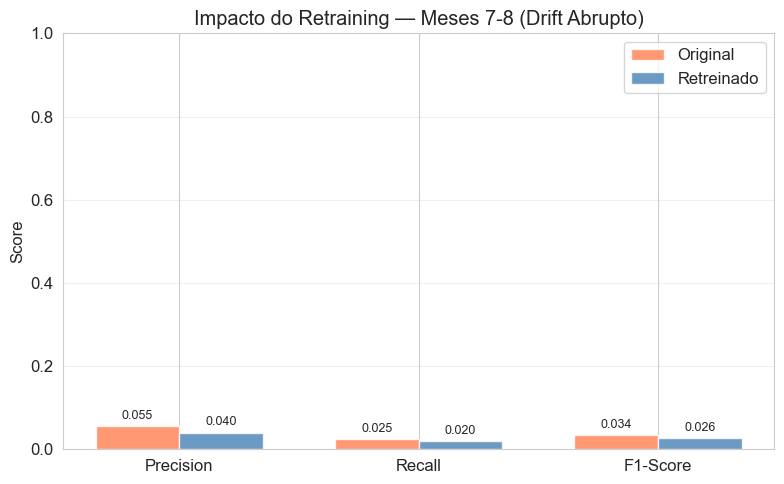

In [13]:
# Visualizar comparação
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(3)
width = 0.35
metrics_labels = ["Precision", "Recall", "F1-Score"]

bars1 = ax.bar(x - width/2, [prec_orig, rec_orig, f1_orig],
               width, label="Original", color="coral", alpha=0.8)
bars2 = ax.bar(x + width/2, [prec_retrain, rec_retrain, f1_retrain],
               width, label="Retreinado", color="steelblue", alpha=0.8)

ax.set_ylabel("Score")
ax.set_title("Impacto do Retraining — Meses 7-8 (Drift Abrupto)")
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 1)

# Anotações
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/retraining_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Relatório Consolidado de Monitoramento

Conforme a seção 'Drift, observabilidade e governança':
> *"Registrar séries temporais de métricas (PSI por feature, p-values, quantis),
> manter contexto (versão do modelo, versão do esquema, janela e amostragem),
> e documentar políticas de resposta."*

In [14]:
# Gerar relatório textual de drift
report = format_drift_report(results)
print(report)

RELATÓRIO DE MONITORAMENTO DE DRIFT

Janela: Mês(es) [np.int64(4)]
  Amostras: 1250
  PSI médio: 0.2695
  PSI máximo: 1.8308
  Features com drift: 5/8
  Alerta: CRITICAL
  >>> TRIGGER DE RETRAINING ATIVADO <<<

Janela: Mês(es) [np.int64(5)]
  Amostras: 1250
  PSI médio: 1.1400
  PSI máximo: 7.8935
  Features com drift: 5/8
  Alerta: CRITICAL
  >>> TRIGGER DE RETRAINING ATIVADO <<<

Janela: Mês(es) [np.int64(6)]
  Amostras: 1250
  PSI médio: 1.7774
  PSI máximo: 11.7187
  Features com drift: 5/8
  Alerta: CRITICAL
  >>> TRIGGER DE RETRAINING ATIVADO <<<

Janela: Mês(es) [np.int64(7)]
  Amostras: 1250
  PSI médio: nan
  PSI máximo: nan
  Features com drift: 6/8
  Alerta: CRITICAL
  >>> TRIGGER DE RETRAINING ATIVADO <<<

Janela: Mês(es) [np.int64(8)]
  Amostras: 1250
  PSI médio: nan
  PSI máximo: nan
  Features com drift: 6/8
  Alerta: CRITICAL
  >>> TRIGGER DE RETRAINING ATIVADO <<<



In [15]:
# Salvar métricas consolidadas
final_metrics = {
    "pipeline_config": {
        "window_size": 1,
        "baseline_months": [1, 2, 3],
        "psi_threshold": 0.25,
        "psi_warning": 0.10,
        "ks_alpha": 0.05,
    },
    "monitoring_summary": metrics,
    "detection_quality": eval_result,
    "retraining_events": retrain_events,
    "model_comparison": {
        "original": {"f1": f1_orig, "precision": prec_orig, "recall": rec_orig},
        "retrained": {"f1": f1_retrain, "precision": prec_retrain, "recall": rec_retrain},
    },
}

save_metrics(final_metrics, "../outputs/logs/final_report.json")
print("Relatório final salvo em outputs/logs/final_report.json")

Relatório final salvo em outputs/logs/final_report.json


## 8. Resumo das Lições Aprendidas — Monitoramento em Escala

Conforme o DOCUMENTO_AULA_7.md, seção 'O Que Você Viu Nesta Aula?':

1. **Data drift e concept drift** degradam modelos em produção, especialmente em Big Data.
2. **Pipelines de streaming** (Kafka + Flink) permitem monitoramento contínuo com baixa latência.
3. **PSI** fornece métrica interpretável; **K–S** oferece critério estatístico formal.
4. **Janelas e amostragem** impactam custo, latência e taxa de falsos alarmes.
5. **Lambda vs. Kappa** influencia a operacionalização do monitoramento.
6. **Auto-retraining** com triggers baseados em drift automatiza a resposta.

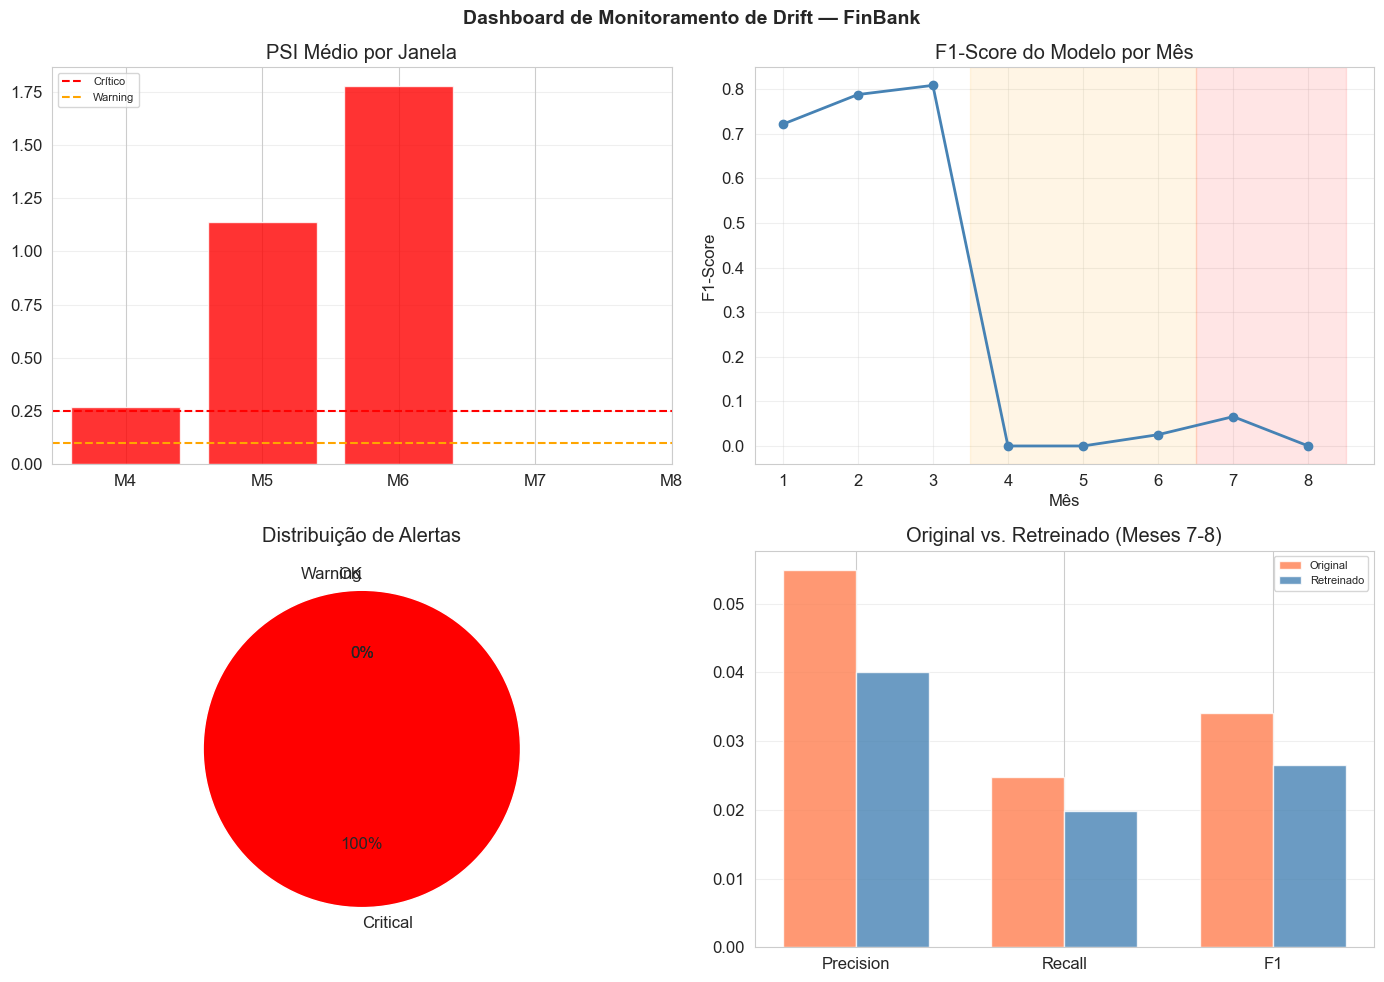

In [16]:
# Dashboard final — visão consolidada
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. PSI timeline
psi_vals = [r["aggregate_score"]["mean_psi"] for r in results]
month_labels = [f"M{r['window_months'][0]}" for r in results]
colors = ["red" if v >= 0.25 else "orange" if v >= 0.10 else "green" for v in psi_vals]
axes[0, 0].bar(range(len(psi_vals)), psi_vals, color=colors, alpha=0.8)
axes[0, 0].axhline(y=0.25, color="red", linestyle="--", label="Crítico")
axes[0, 0].axhline(y=0.10, color="orange", linestyle="--", label="Warning")
axes[0, 0].set_xticks(range(len(month_labels)))
axes[0, 0].set_xticklabels(month_labels)
axes[0, 0].set_title("PSI Médio por Janela")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(axis="y", alpha=0.3)

# 2. Performance do modelo
axes[0, 1].plot(perf_df["Mês"], perf_df["f1"], marker="o", color="steelblue", linewidth=2)
axes[0, 1].axvspan(3.5, 6.5, alpha=0.1, color="orange")
axes[0, 1].axvspan(6.5, 8.5, alpha=0.1, color="red")
axes[0, 1].set_xlabel("Mês")
axes[0, 1].set_ylabel("F1-Score")
axes[0, 1].set_title("F1-Score do Modelo por Mês")
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_xticks(range(1, 9))

# 3. Distribuição de alertas
alert_counts = [metrics["ok_windows"], metrics["warning_windows"], metrics["critical_windows"]]
alert_labels = ["OK", "Warning", "Critical"]
alert_colors = ["green", "orange", "red"]
axes[1, 0].pie(alert_counts, labels=alert_labels, colors=alert_colors,
               autopct="%1.0f%%", startangle=90)
axes[1, 0].set_title("Distribuição de Alertas")

# 4. Comparação original vs. retreinado
x = np.arange(3)
width = 0.35
axes[1, 1].bar(x - width/2, [prec_orig, rec_orig, f1_orig],
               width, label="Original", color="coral", alpha=0.8)
axes[1, 1].bar(x + width/2, [prec_retrain, rec_retrain, f1_retrain],
               width, label="Retreinado", color="steelblue", alpha=0.8)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(["Precision", "Recall", "F1"])
axes[1, 1].set_title("Original vs. Retreinado (Meses 7-8)")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(axis="y", alpha=0.3)

plt.suptitle("Dashboard de Monitoramento de Drift — FinBank",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/dashboard_final.png", dpi=150, bbox_inches="tight")
plt.show()

## Resumo

Neste notebook:

1. **Avaliamos** o impacto do drift no desempenho do modelo de fraude (F1 degrada ao longo dos meses).
2. **Comparamos** matrizes de confusão entre baseline e período de drift abrupto.
3. **Avaliamos** a qualidade da detecção de drift (precision/recall do pipeline de monitoramento).
4. **Implementamos** triggers automáticos de retraining baseados em playbooks de drift.
5. **Demonstramos** o benefício do retraining: recuperação de performance.
6. **Geramos** relatório consolidado de monitoramento para governança.

### Conclusão da Aula 7

Conforme sintetizado no DOCUMENTO_AULA_7.md:
> *"Drift é inevitável; surpresa não precisa ser. Monitoramento em escala exige
> arquitetura, estatística e governança trabalhando juntas."*